## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [ ]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A/test_models/"
path_to_predictions = pre_path + "predictions/model_A/test_models/"
tag = "test_categories"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
# display(iso_df)
# data_visualiser = Data_visualiser(iso_df, physical_model)
# data_visualiser.plot_Kiel([], [0.0])

Reading MIST dataframe from csv file...


In [5]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3, 4, 5]})
display(phase_filtered_iso_df)
# data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
# data_visualiser_phase_filtered.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
1140739,10.3,3.425746,-0.551440,5.0,0.50,0.602856,2.384899
1140740,10.3,3.426469,-0.560350,5.0,0.50,0.598549,2.387797
1140741,10.3,3.427744,-0.566057,5.0,0.50,0.594116,2.389036
1140742,10.3,3.429413,-0.569225,5.0,0.50,0.589648,2.388981


In [6]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.4657, Median : 8.55

log_Teff  : Range : 3.34 - 5.3788, Mean : 3.8298, Median : 3.6739

log_g  : Range : -1.14 - 6.2594, Mean : 2.0665, Median : 2.005

Values in phase column : 0.0, 2.0, 3.0, 4.0, 5.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 7.5368, Median : 2.0818

log_R  : Range : -1.0 - 3.1298, Mean : 1.3949, Median : 1.5001



In [ ]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)
print(categories_train.shape, categories_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.0816081316727946
Mean value in train data for the star_mass parameter: 7.558407372495925

Range in train data for the log_R parameter : -0.9974747647513328 - 3.129269620812593
Median value in train data for the log_R parameter: 1.4993114860984695
Mean value in train data for the log_R parameter: 1.3944707591667809

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 296.5221171165397
Median value in test data for the star_mass parameter: 2.082595606409119
Mean value in test data for the star_mass parameter: 7.471864103970097

Range in test data for the log_R parameter : -0.9974234436680278 - 3.1297545143214007
Median value in test data for the log_R parameter: 1.5026448988619927
Mean value in test data for the log_R parameter: 1.396340263115711

(855558, 4) (285186, 4)
(85555

## Model training

### Linear regression

In [8]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


test_categories train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
5
5

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.27106458392624055
  RMSE :  22.3791370688482
  MAE :  13.22023481220837
  MedAE :  11.59419191229083
  CORR :  0.5323260018606589
  MAX_ER :  257.21540163374084
  Percentiles : 
    75th percentile :  15.840592353455747
    90th percentile :  18.48622845917761
    95th percentile :  20.401348548261225
    99th percentile :  101.05238801083435

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.7634895243517
  RVE :  0.3099241764763535
  RMSE :  24.837159794826867
  MAE :  9.79333924012701
  MedAE :  4.427411878321513
  CORR :  0.5810701302871768
  MAX_ER :  248.38959195229725
  Percentiles : 
    75th percentile :  10.595366819317821
    90th percentile :  14.561868307901186
    95th percentile :  25.6658819974

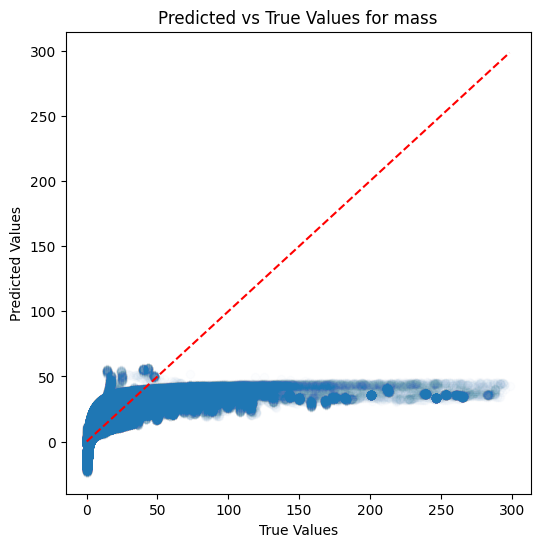

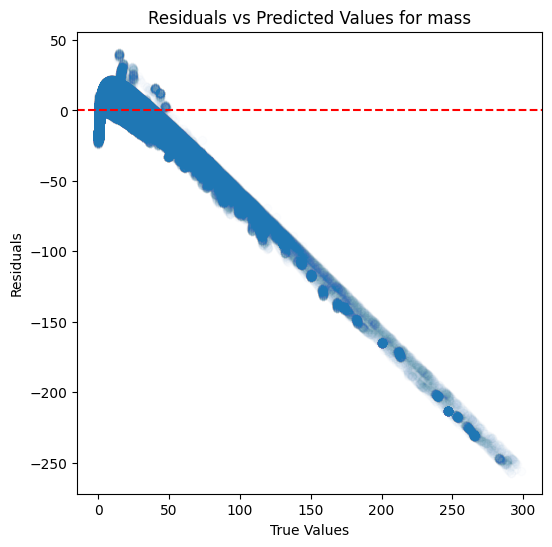

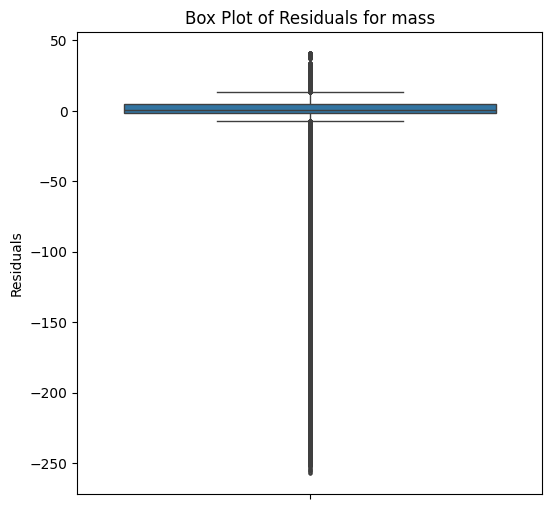

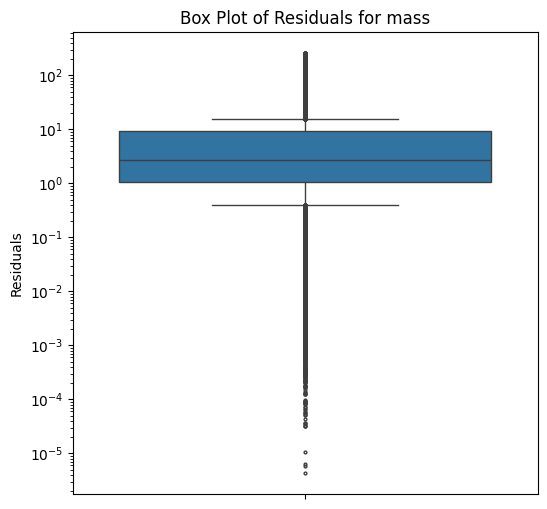

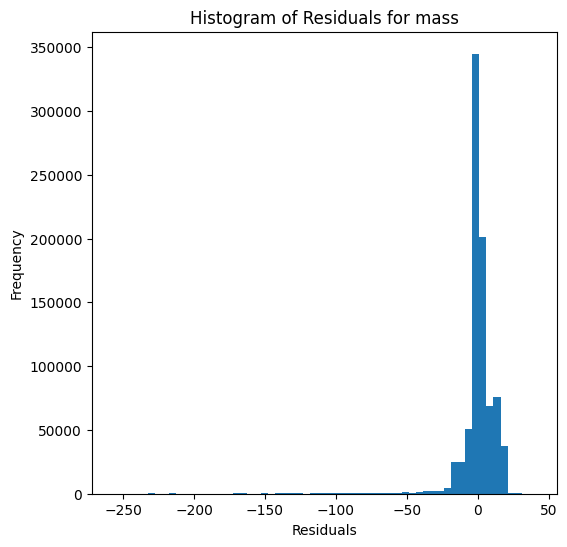

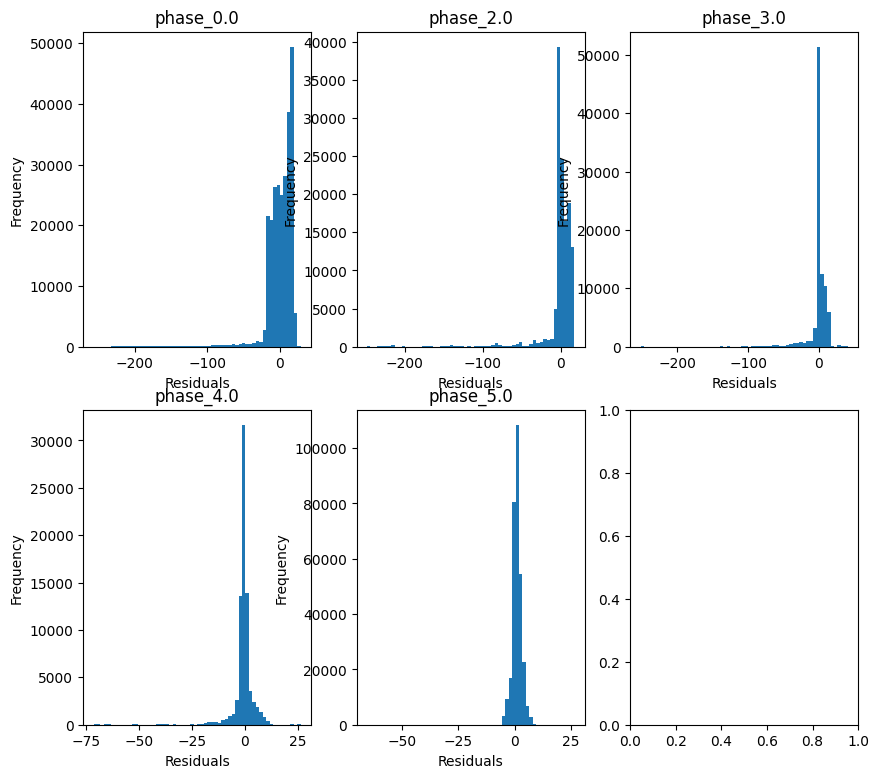

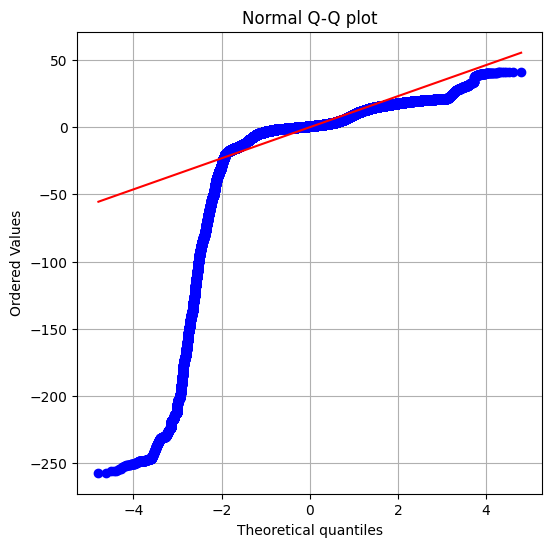

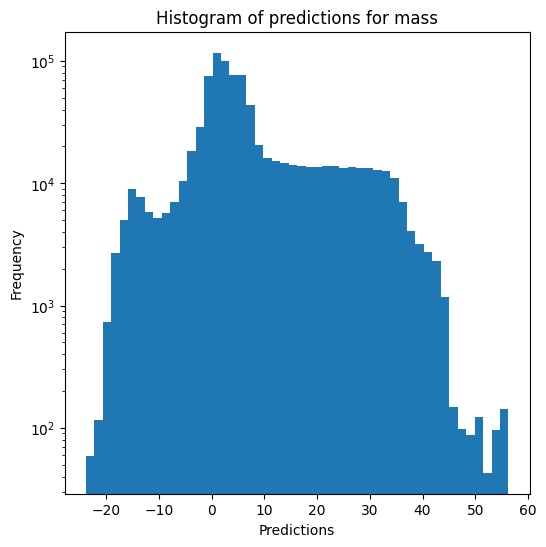

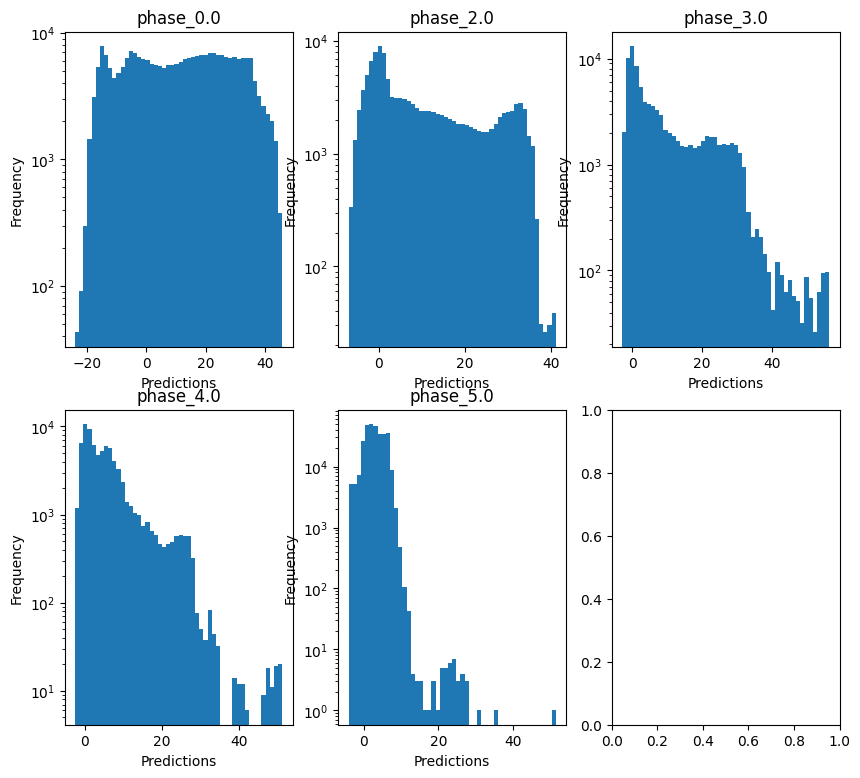

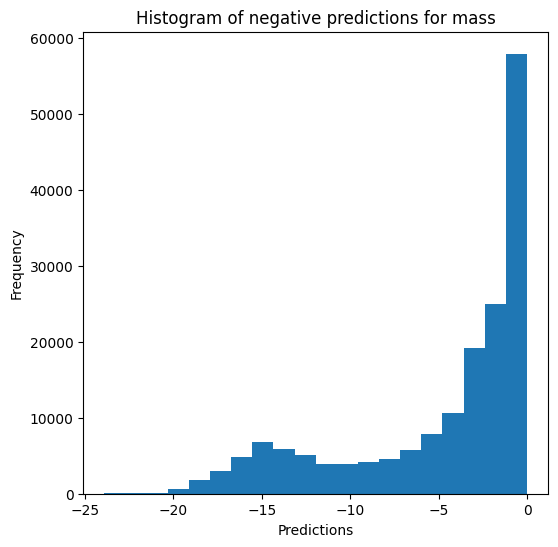

5
5

radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9655145379641561
  RMSE :  0.10991897372439777
  MAE :  0.08656742689857565
  MedAE :  0.06968407453176642
  CORR :  0.9826130877462592
  MAX_ER :  0.48589006867375195
  Percentiles : 
    75th percentile :  0.12499567172313275
    90th percentile :  0.1865626482775193
    95th percentile :  0.21967381619427953
    99th percentile :  0.26896877996916857

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.891706235288321
  RVE :  0.9763386441074037
  RMSE :  0.09579171718327643
  MAE :  0.06619487500758411
  MedAE :  0.04802213202816036
  CORR :  0.9890040190329744
  MAX_ER :  0.47973863393032734
  Percentiles : 
    75th percentile :  0.0902419100776608
    90th percentile :  0.13388183740686702
    95th percentile :  0.18808041503087622
    99th percentile :  0.38332249314588024

radius results for the phase 

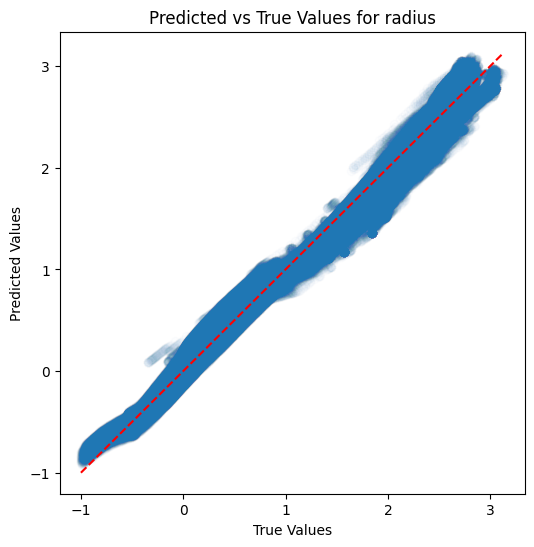

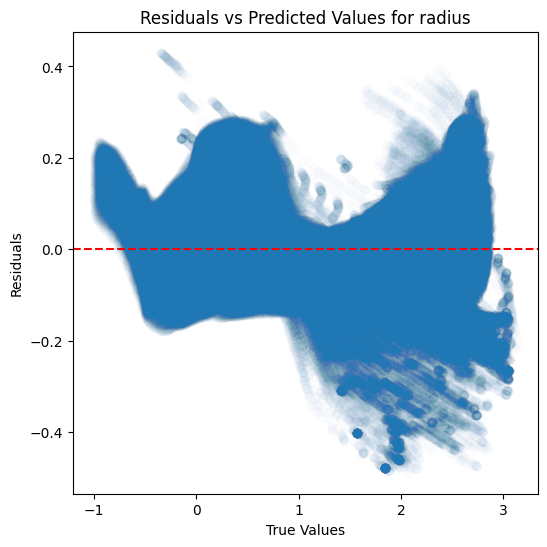

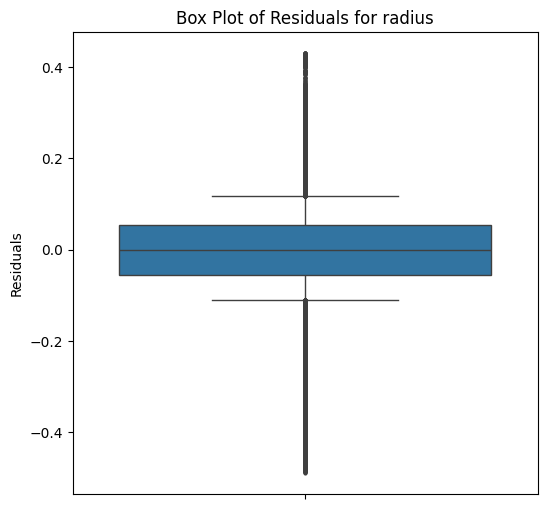

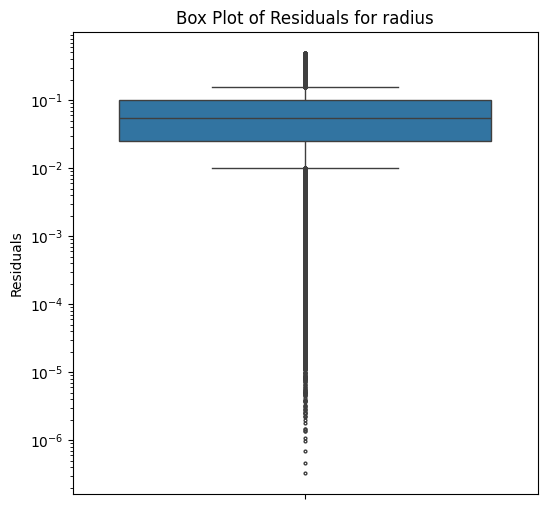

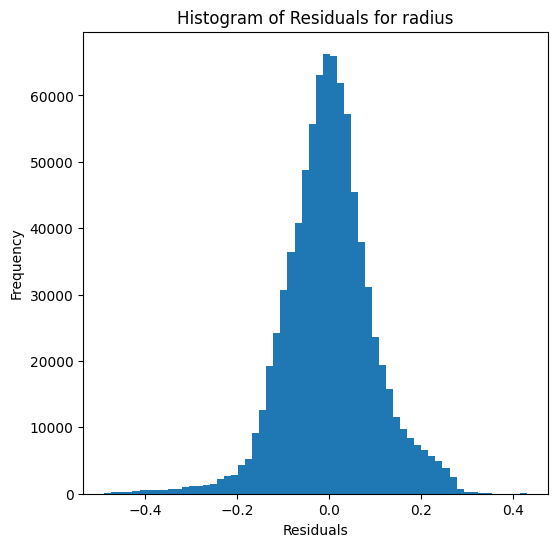

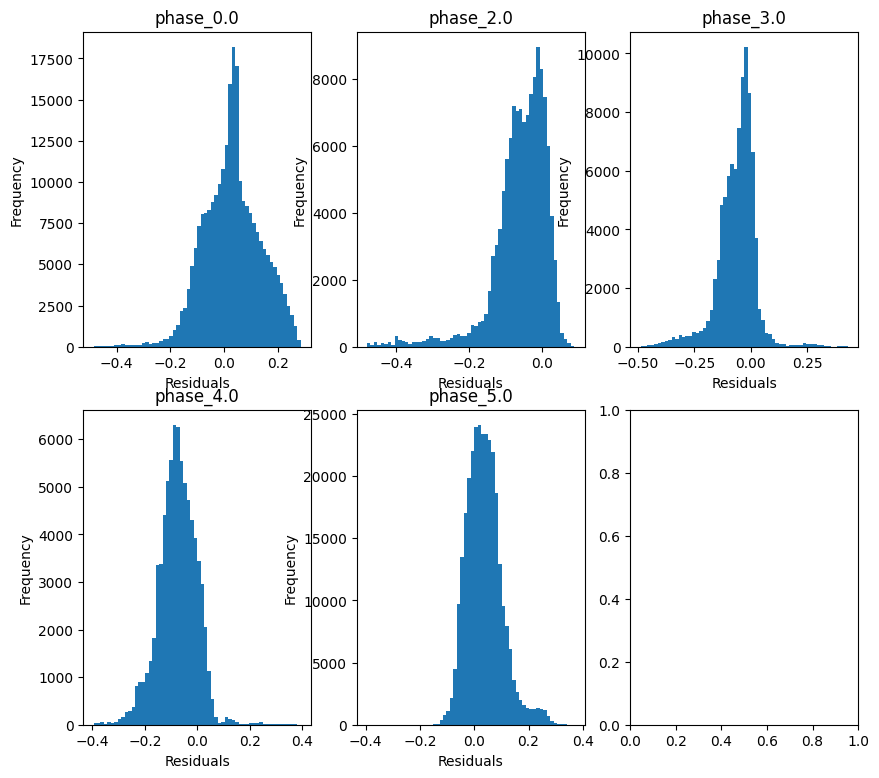

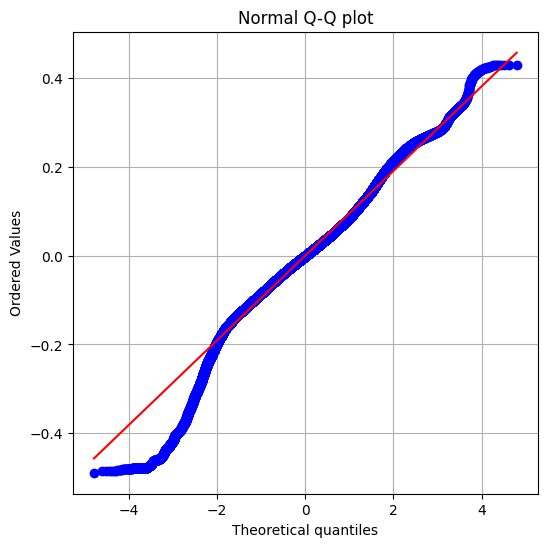

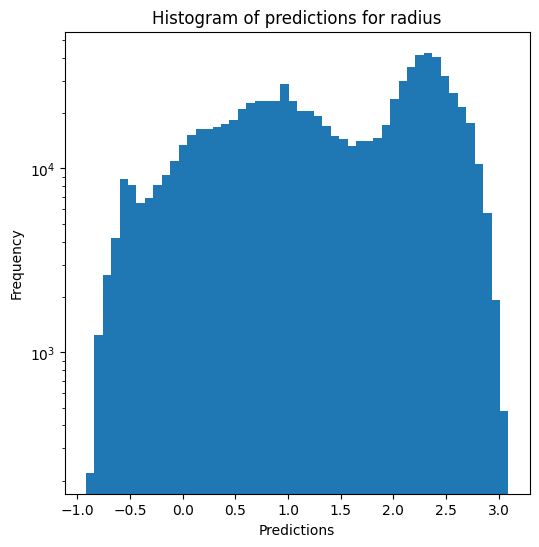

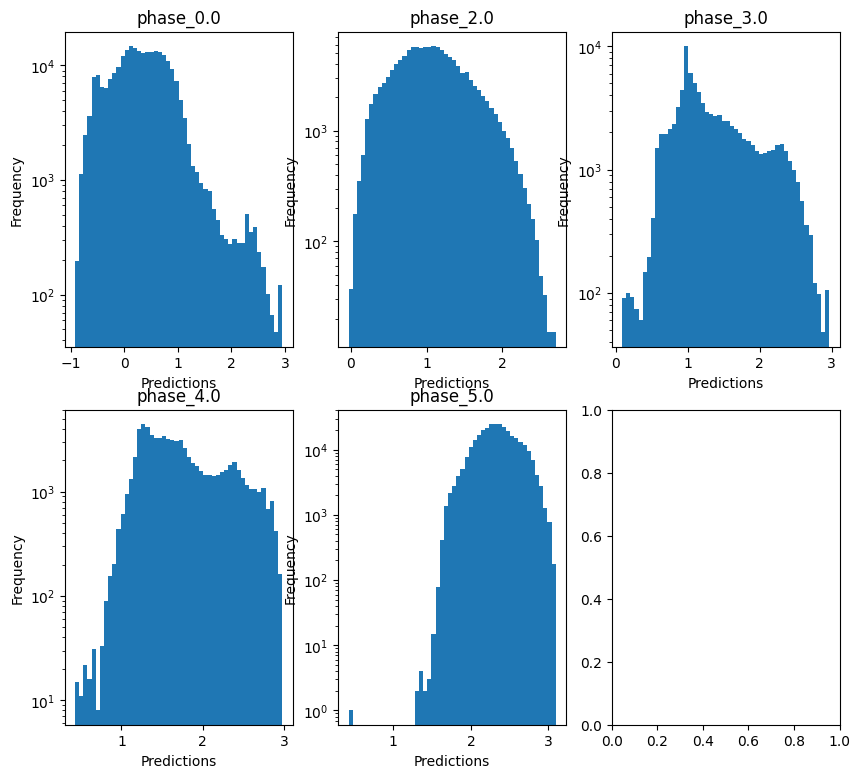

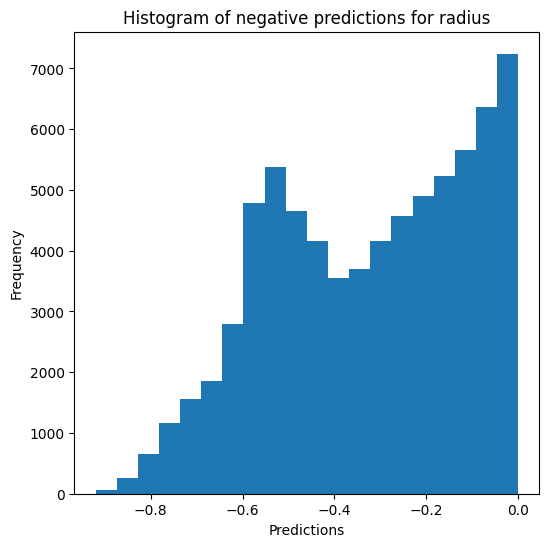

In [9]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=False, show=True) #, override=False, use_preds=True)


test_categories train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.27106458392624055
  RMSE :  22.3791370688482
  MAE :  13.22023481220837
  MedAE :  11.59419191229083
  CORR :  0.5323260018606589
  MAX_ER :  257.21540163374084
  Percentiles : 
    75th percentile :  15.840592353455747
    90th percentile :  18.48622845917761
    95th percentile :  20.401348548261225
    99th percentile :  101.05238801083435
mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.7634895243517
  RVE :  0.3099241764763535
  RMSE :  24.837159794826867
  MAE :  9.79333924012701
  MedAE :  4.427411878321513
  CORR :  0.5810701302871768
  MAX_ER :  248.38959195229725
  Percentiles : 
    75th percentile :  10.595366819317821
    90th percentile :  14.561868307901186
    95th percentile :  25.665881997414044
    99th percentile :  139.57206423465695
mass r

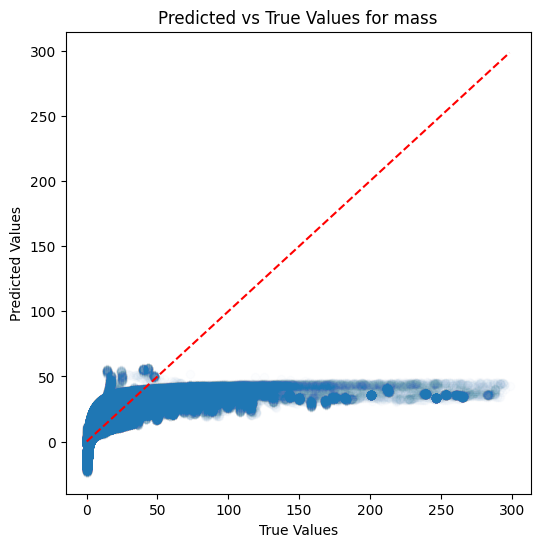

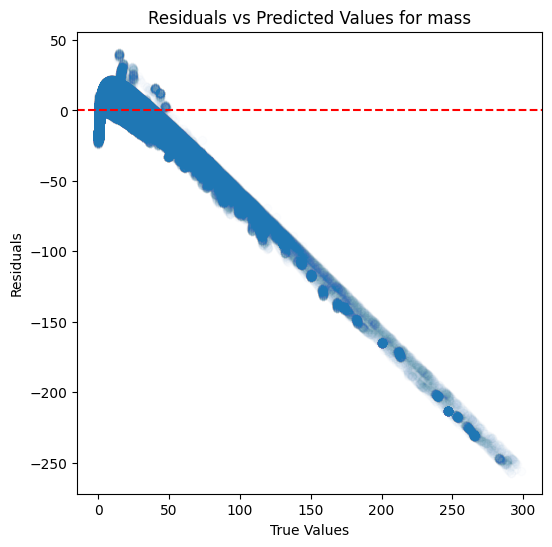

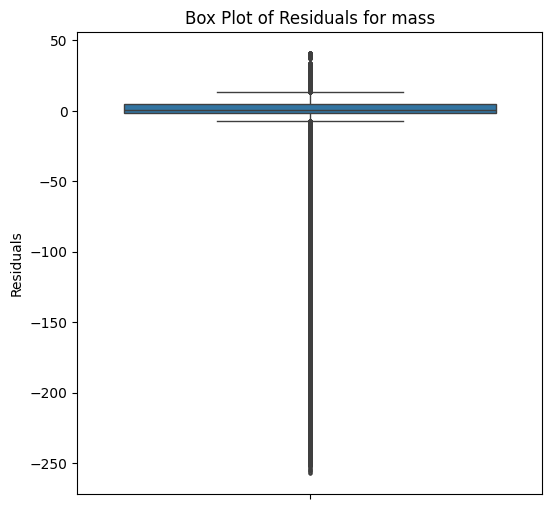

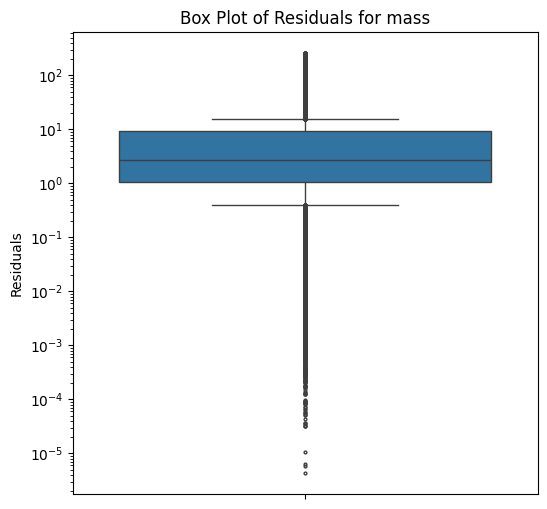

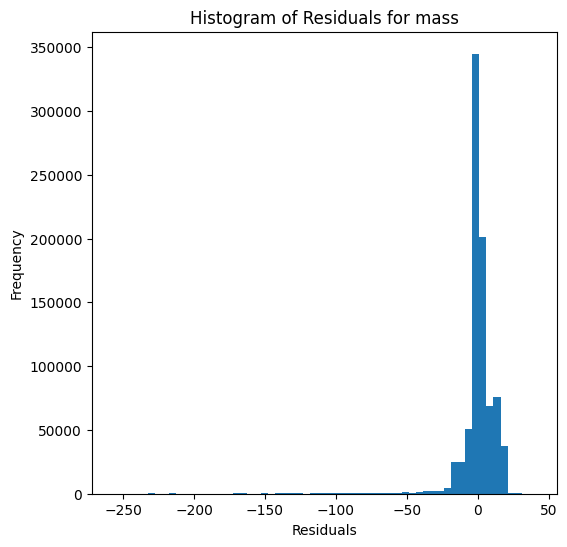

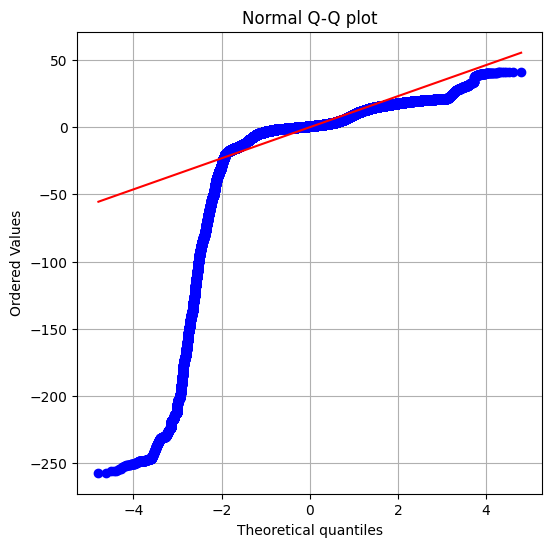

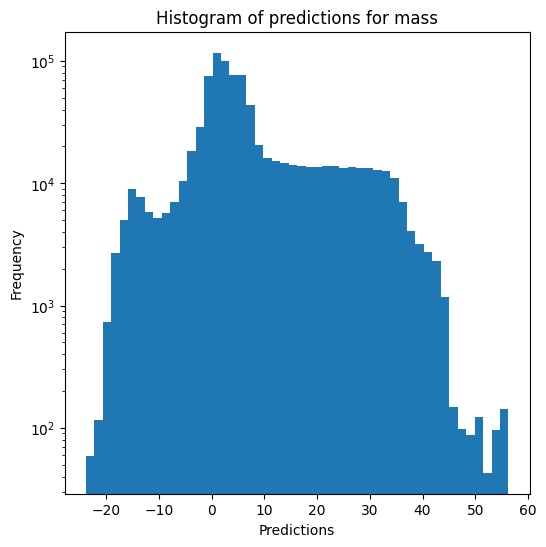

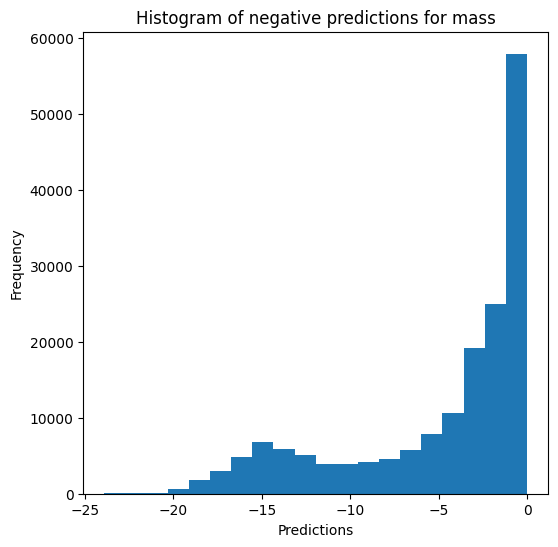


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9655145379641561
  RMSE :  0.10991897372439777
  MAE :  0.08656742689857565
  MedAE :  0.06968407453176642
  CORR :  0.9826130877462592
  MAX_ER :  0.48589006867375195
  Percentiles : 
    75th percentile :  0.12499567172313275
    90th percentile :  0.1865626482775193
    95th percentile :  0.21967381619427953
    99th percentile :  0.26896877996916857
radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.891706235288321
  RVE :  0.9763386441074037
  RMSE :  0.09579171718327643
  MAE :  0.06619487500758411
  MedAE :  0.04802213202816036
  CORR :  0.9890040190329744
  MAX_ER :  0.47973863393032734
  Percentiles : 
    75th percentile :  0.0902419100776608
    90th percentile :  0.13388183740686702
    95th percentile :  0.18808041503087622
    99th percentile :  0.38332249314588024
radius results for the phase catego

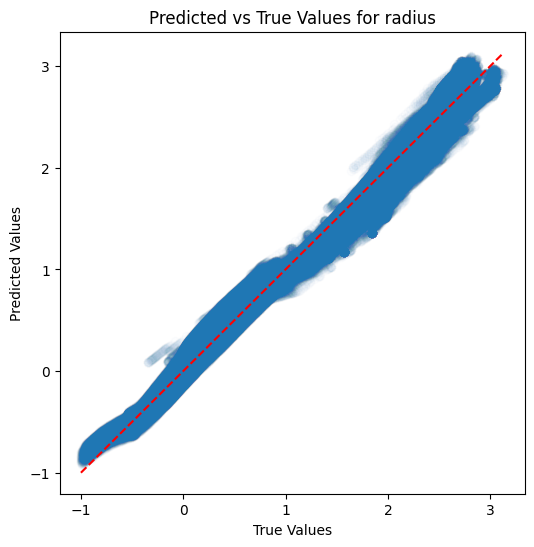

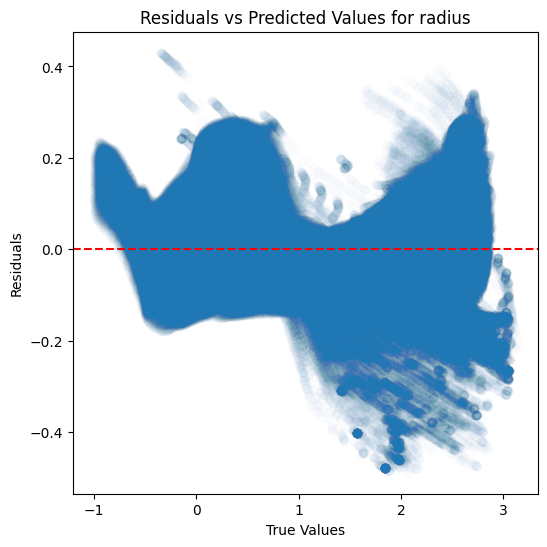

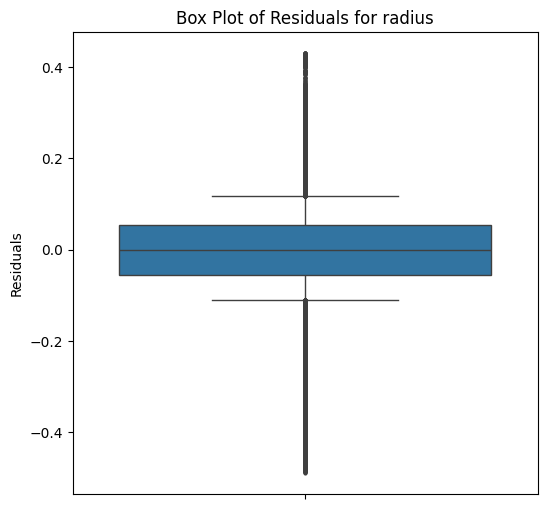

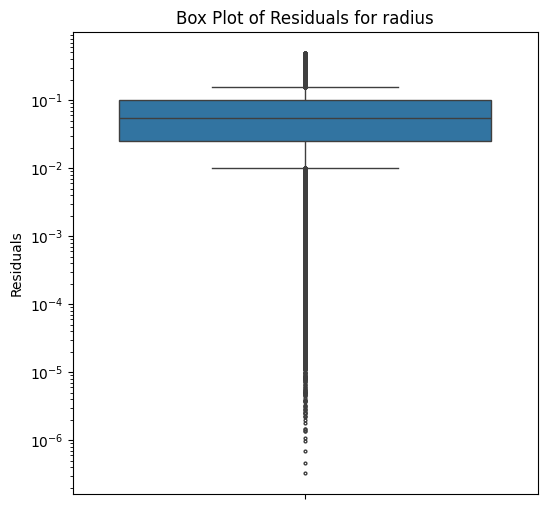

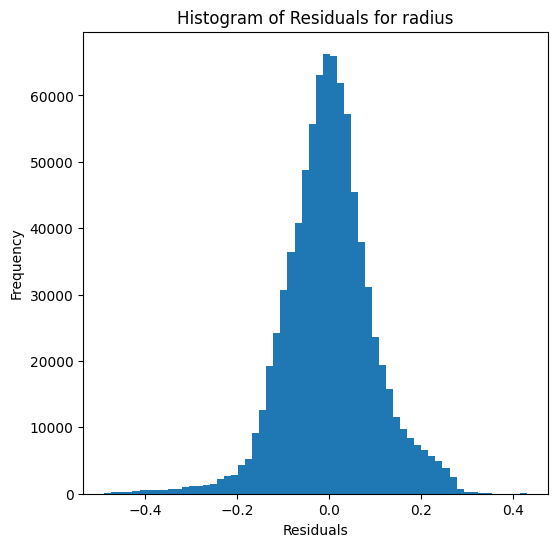

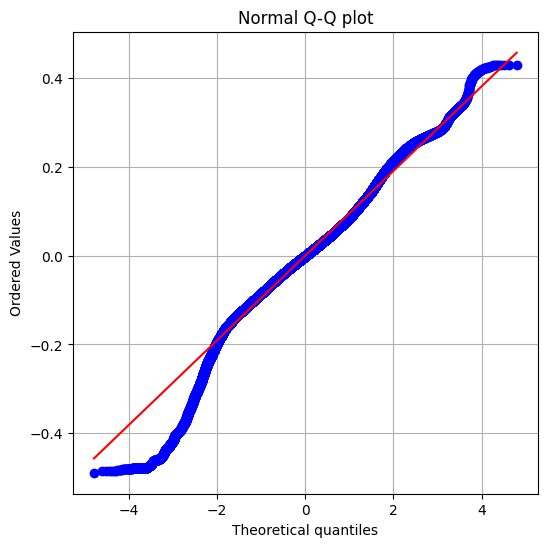

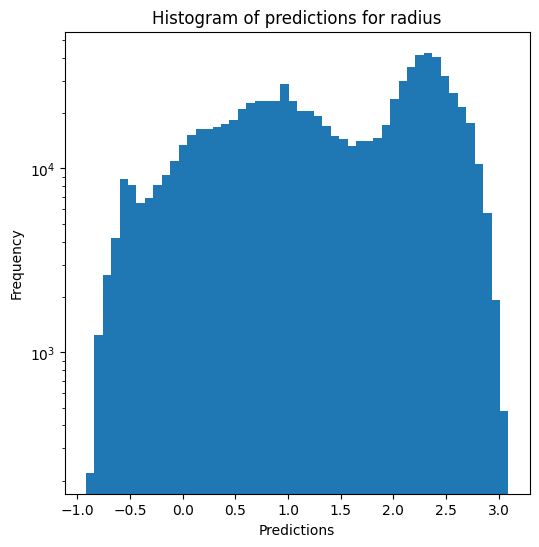

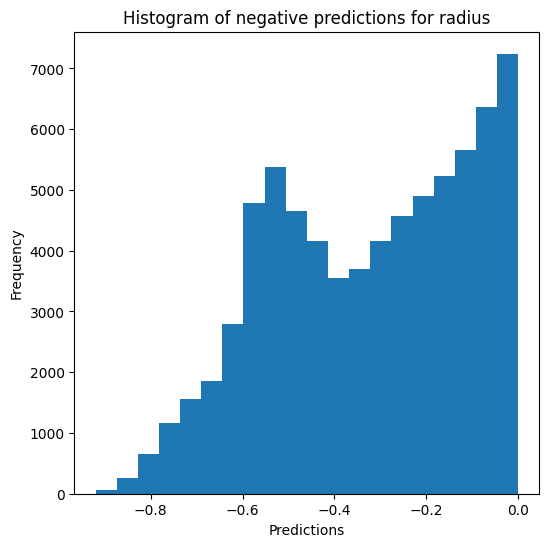

In [9]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=False, show=True) #, override=False, use_preds=True)